# Base Model vs SFT Model — Comparison

This notebook quantitatively benchmarks how **Supervised Fine-Tuning (SFT)** on AWS-CLI traces improves an off-the-shelf code model. Two models go head-to-head:

- **Base** — `unsloth/Qwen2.5-Coder-3B-Instruct-bnb-4bit` (no fine-tuning, 4-bit)
- **SFT** — same base + LoRA adapter (`Sizzing/aws-rl-sft-qwen25coder3b-adapter`) trained on the AWS RL dataset

Two evaluation modes — run one or both:

| Mode | What it tests | Needs |
|---|---|---|
| **Dataset eval** | Static pattern matching on held-out prompts | HF token + dataset access |
| **RL env eval** | Live multi-turn task completion against the AWS environment | Dataset eval above + running HF Space |

**RL env metrics (per episode)**

| Metric | What it measures |
|---|---|
| `avg_episode_reward` | Mean total reward accumulated per episode |
| `completion_rate` | % episodes the model completed the task before hitting max steps |
| `avg_steps` | Mean number of AWS commands issued per episode |
| `avg_reward_per_step` | Mean per-step reward (efficiency) |
| `reward_std` | Reward variance across episodes (consistency) |

**Before running:**
1. Runtime → Change runtime type → GPU (T4)
2. Fill in the Config cell below
3. Add `HF_TOKEN` to Colab Secrets (🔑 left sidebar)


## ⚙️ Configuration

This block centralises every knob for the run. Two clusters of settings:

- **Identity / endpoints** — which model artefacts, dataset, and RL env to talk to (`BASE_MODEL`, `SFT_ADAPTER_REPO`, `DATASET_REPO`, `REPO_URL`, `ENV_BASE_URL`).
- **Eval budget** — how much to evaluate. `EVAL_MAX_PER_COMBO=2` means up to 2 rows per (difficulty, source) combo for the dataset eval. `RL_EPISODES_PER_DIFF=3` × 5 tiers = **15 RL episodes per model**. `MAX_EPISODE_STEPS=15` caps how many AWS commands an agent gets per episode before we call it a timeout.

`MAX_SEQ_LENGTH=512` is what keeps everything on a 16 GB T4. Two `assert`s at the bottom catch the most common footgun — leaving `YOUR_USERNAME` placeholders in the URLs.

> **Output:** `Config OK` confirms placeholders were replaced and the run can proceed.


In [3]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
BASE_MODEL        = "unsloth/Qwen2.5-Coder-3B-Instruct-bnb-4bit"
SFT_ADAPTER_REPO  = "Sizzing/aws-rl-sft-qwen25coder3b-adapter"   # HF Hub or local path
DATASET_REPO      = "Sizzing/aws-rl-sft"
REPO_URL          = "https://github.com/bangar1/aws-rl-env-fork"  # your fork
ENV_BASE_URL      = "https://bangar-hf-aws-rl-env.hf.space/"        # HF Space URL

# Dataset eval knobs
MAX_SEQ_LENGTH     = 512
MAX_NEW_TOKENS     = 120
EVAL_MAX_PER_COMBO = 2     # rows per (difficulty, source) combo

# RL env eval knobs — difficulty tiers: warmup, beginner, intermediate, advanced, expert
RL_EPISODES_PER_DIFF = 3   # episodes per difficulty tier
MAX_EPISODE_STEPS    = 15  # max AWS commands per episode
TEMPERATURE          = 0.7

IS_COLAB = True
# ───────────────────────────────────────────────────────────────────────────
assert "YOUR_USERNAME" not in ENV_BASE_URL, "Set ENV_BASE_URL to your HF Space URL"
assert "YOUR_USERNAME" not in REPO_URL,    "Set REPO_URL to your fork URL"
print("Config OK")

Config OK


## 📦 Install Dependencies

Installs the GPU stack we'll need:

- `unsloth` — 4-bit LoRA inference (fast, T4-friendly)
- `transformers >=4.50, <5.0` — pinned to a working range for unsloth
- `trl <0.12.0`, `peft`, `accelerate`, `datasets` — fine-tuning + dataset utilities
- `bitsandbytes` — quantization backend
- `httpx`, `websockets`, `nest_asyncio` — async client for the RL env
- `matplotlib`, `numpy` — plots

The `%%capture` magic suppresses pip noise — only failures will surface here.


In [15]:
%%capture
!pip install -q --upgrade pip
!pip install -q unsloth
!pip install -q --force-reinstall --no-deps "transformers>=4.50,<5.0"
!pip install -q --upgrade "trl<0.12.0" peft accelerate datasets huggingface_hub bitsandbytes
!pip install -q matplotlib numpy httpx websockets nest_asyncio

## 🧬 Clone the AWS RL Env Repo

Pulls a shallow clone of the RL-env fork into `/content/aws-rl-env`, installs it as an editable package (`pip install -e .`), and prepends the path to `sys.path` so later imports like `from client import AwsRlEnv` resolve to this clone.

If the directory already exists (e.g. a re-run), it's wiped first to guarantee a clean state.

> **Output:** confirms the directory was recreated and the editable install completed. The `Building editable …` lines are normal `pip install -e` chatter.


In [22]:
import subprocess, sys
import shutil

REPO_DIR = "/content/aws-rl-env"

# Remove the directory if it already exists
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print(f"Removed existing directory: {REPO_DIR}")

subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
!pip install -q -e /content/aws-rl-env   # ← add this

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print("Repo ready at", REPO_DIR)

Removed existing directory: /content/aws-rl-env
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for openenv-aws_rl_env (pyproject.toml) ... done
Repo ready at /content/aws-rl-env


## 🎯 GPU & Runtime Detection

Picks the right floating-point format for whatever GPU Colab handed out:

- **T4** → `fp16` (no native bfloat16 support)
- **Anything newer** (A100, L4, etc.) → `bf16`

`nest_asyncio.apply()` lets us drive `async` env-client calls from inside notebook cells (Jupyter already owns the outer event loop). `PYTORCH_ALLOC_CONF=expandable_segments:True` reduces VRAM fragmentation when models load and unload.

> **Output:** GPU name, total VRAM (~15.6 GB on T4), and the chosen precision. If you ever see `No GPU` here, change runtime type and re-run.


In [18]:
import os, gc, time, json, math, asyncio, logging
from dataclasses import dataclass, field
from typing import List, Tuple
import torch
import nest_asyncio
nest_asyncio.apply()

os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

assert torch.cuda.is_available(), "No GPU — Runtime → Change runtime type → GPU"
gpu     = torch.cuda.get_device_properties(0)
IS_T4   = "T4" in gpu.name
USE_FP16 = IS_T4
USE_BF16 = not IS_T4
print(f"GPU  : {gpu.name}")
print(f"VRAM : {gpu.total_memory / 1e9:.1f} GB")
print(f"Prec : {'fp16' if USE_FP16 else 'bf16'}")

GPU  : Tesla T4
VRAM : 15.6 GB
Prec : fp16


## 🔐 Hugging Face Authentication

Reads `HF_TOKEN` from Colab Secrets, exports it to the env, and authenticates the session so `from_pretrained(...)` calls can pull both the base model and the (potentially gated) SFT adapter.

> **Output:** `HF authenticated`. The "Note: Environment variable `HF_TOKEN` is set …" line is informational — `huggingface_hub` is just telling you it sees an existing token in the env, not an error.


In [7]:
if IS_COLAB:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

assert os.environ.get("HF_TOKEN"), "Set HF_TOKEN in Colab Secrets"

from huggingface_hub import login as hf_login
hf_login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
print("HF authenticated")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF authenticated


## 🩺 RL Env Health Check

Quick HTTP ping to the HF Space hosting the AWS RL environment, mainly to wake the Space if it's been idle.

> **Output:** `404` here is **expected** — this Space's root router doesn't expose a literal `/health` endpoint. What matters is that we got *any* response (the Space is awake and answering). The real session is opened later via a websocket inside `AwsRlEnv(...).connect()`.


In [8]:
import httpx

with httpx.Client(timeout=15) as c:
    r = c.get(f"{ENV_BASE_URL}/health")
    print("RL env server:", r.status_code, r.json())

RL env server: 404 {'detail': 'Not Found'}


---
# Part 1 — Dataset Eval (static)

A **fast, deterministic, offline** check. We sample a few held-out prompts from the validation split and ask each model what AWS CLI command it would emit. We never hit the live RL env here — every metric is computed by string-comparing the generated command to the gold-standard one in the dataset.

This catches **format drift** (does the model produce parseable single-line commands?) and **service / operation accuracy** (does it pick the right AWS API and verb?).


## 📚 Load the Evaluation Dataset

Streams the AWS-RL dataset from the Hub. Three splits:

- **train** (1,500 rows) — what the SFT was trained on
- **validation** (150 rows) — held out, this is what we score on
- **reserve** (200 rows) — kept for downstream RL training

Each row contains `task_id`, `difficulty`, `source`, `step_idx`, and a chat-style `messages` list. The last assistant turn is the gold AWS CLI command we'll grade against.

> **Output:** the `DatasetDict` printout confirms all three splits loaded with the expected row counts (1500 / 150 / 200).


In [9]:
from datasets import load_dataset

ds = load_dataset(DATASET_REPO, token=os.environ["HF_TOKEN"])
print(ds)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.92M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/194k [00:00<?, ?B/s]

data/reserve-00000-of-00001.parquet:   0%|          | 0.00/261k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/150 [00:00<?, ? examples/s]

Generating reserve split:   0%|          | 0/200 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['task_id', 'difficulty', 'source', 'step_idx', 'messages'],
        num_rows: 1500
    })
    validation: Dataset({
        features: ['task_id', 'difficulty', 'source', 'step_idx', 'messages'],
        num_rows: 150
    })
    reserve: Dataset({
        features: ['task_id', 'difficulty', 'source', 'step_idx', 'messages'],
        num_rows: 200
    })
})


## 🧮 Scoring Helpers

These helpers run the eval and break "correctness" into five increasingly forgiving metrics so we can see *where* a model fails (formatting? wrong service? wrong flags?):

| Metric | Pass condition |
|---|---|
| `format_pct` | Generation **starts with** `aws ` (no preamble, no markdown fence) |
| `format_after_extract_pct` | After stripping fences/prose, *some* line starts with `aws ` |
| `exact_pct` | Extracted command matches the gold command character-for-character |
| `service_pct` | Same AWS service (e.g. `s3`, `ec2`) as gold |
| `operation_pct` | Same service **and** operation (e.g. `s3 ls`) as gold |

Plus `avg_latency` and `avg_len` to gauge speed and verbosity.

`build_eval_set` picks up to 2 prompts per `(difficulty, source)` combo so the eval is balanced across difficulty tiers — small but representative.

> **Output:** `Eval set: 18 prompts across 9 (tier, source) combos` — that's the deterministic eval surface used by both models.


In [10]:
def extract_command(raw: str) -> str:
    text = raw.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        text = "\n".join(l for l in lines if not l.startswith("```")).strip()
    for line in text.split("\n"):
        line = line.strip()
        if line.startswith("aws "):
            return line
    return text


def score_row(completion: str, expected: str) -> dict:
    extracted  = extract_command(completion)
    e_tokens   = extracted.split()
    exp_tokens = expected.split()
    return {
        "format_ok":            completion.strip().startswith("aws "),
        "format_after_extract": extracted.startswith("aws "),
        "exact":                extracted == expected.strip(),
        "service":              (len(e_tokens) >= 2 and len(exp_tokens) >= 2
                                 and e_tokens[1:2] == exp_tokens[1:2]),
        "operation":            (len(e_tokens) >= 3 and len(exp_tokens) >= 3
                                 and e_tokens[2:3] == exp_tokens[2:3]),
    }


def build_eval_set(dataset, max_per_combo: int = 2):
    seen, picks = {}, []
    for r in dataset:
        key = (r["difficulty"], r["source"])
        seen[key] = seen.get(key, 0) + 1
        if seen[key] <= max_per_combo:
            picks.append(r)
    return picks


def dataset_eval(model, tokenizer, eval_set, max_new_tokens: int = 120) -> dict:
    results = []
    model.eval()
    for row in eval_set:
        msgs     = row["messages"][:2]
        expected = row["messages"][2]["content"]
        prompt   = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        t0 = time.time()
        with torch.inference_mode():
            out_ids = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False, temperature=0.0,
                pad_token_id=tokenizer.eos_token_id,
            )
        dt         = time.time() - t0
        completion = tokenizer.decode(
            out_ids[0, inputs.input_ids.shape[1]:], skip_special_tokens=True
        )
        s = score_row(completion, expected)
        s.update({"latency": dt, "len": len(completion),
                  "completion": completion, "expected": expected})
        results.append(s)

    n = len(results)
    return {
        "format_pct":               sum(r["format_ok"]            for r in results) / n,
        "format_after_extract_pct": sum(r["format_after_extract"] for r in results) / n,
        "exact_pct":                sum(r["exact"]                for r in results) / n,
        "service_pct":              sum(r["service"]              for r in results) / n,
        "operation_pct":            sum(r["operation"]            for r in results) / n,
        "avg_latency":              sum(r["latency"]              for r in results) / n,
        "avg_len":                  sum(r["len"]                  for r in results) / n,
        "_per_row":                 results,
    }


EVAL_SET = build_eval_set(ds["validation"], max_per_combo=EVAL_MAX_PER_COMBO)
combos   = len(set((r["difficulty"], r["source"]) for r in EVAL_SET))
print(f"Eval set: {len(EVAL_SET)} prompts across {combos} (tier, source) combos")

Eval set: 18 prompts across 9 (tier, source) combos


## 🧪 Base Model — Dataset Eval

Loads the un-finetuned `Qwen2.5-Coder-3B-Instruct` in 4-bit, runs the 18-prompt eval at `temperature=0` (greedy, reproducible), then unloads it from VRAM so the SFT model can fit next.

> **Output (Base):**
>
> | Metric | Value | What it means |
> |---|---|---|
> | `format_pct` | **33.3%** | Only ⅓ of generations start cleanly with `aws ` |
> | `format_after_extract_pct` | **100%** | But every output has *some* `aws` line buried inside it |
> | `exact_pct` | **38.9%** | Fewer than half match the reference exactly |
> | `service_pct` | **77.8%** | Usually picks the right AWS service |
> | `operation_pct` | **61.1%** | Right operation about 60% of the time |
> | `avg_latency` | 1.90 s | Per-prompt generation time |
> | `avg_len` | 85.8 chars | Average response length |
>
> **Reading:** the base model usually picks the right *service*, but is verbose, often wraps commands in markdown or English prose, and gets the operation/flags wrong about 40% of the time.


In [11]:
from unsloth import FastLanguageModel

print("Loading base model...")
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL, max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, dtype=None,
)
FastLanguageModel.for_inference(base_model)

print("Running base model dataset eval...")
base_ds_metrics = dataset_eval(base_model, base_tokenizer, EVAL_SET,
                               max_new_tokens=MAX_NEW_TOKENS)

print("\n=== BASE — Dataset Eval ===")
for k, v in base_ds_metrics.items():
    if k == "_per_row": continue
    print(f"  {k:<30} {100*v:6.1f}%" if "pct" in k else f"  {k:<30} {v:.3f}")

del base_model, base_tokenizer
gc.collect(); torch.cuda.empty_cache()
print("\nBase model unloaded.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Loading base model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running base model dataset eval...

=== BASE — Dataset Eval ===
  format_pct                       33.3%
  format_after_extract_pct        100.0%
  exact_pct                        38.9%
  service_pct                      77.8%
  operation_pct                    61.1%
  avg_latency                    1.901
  avg_len                        85.833

Base model unloaded.


## 🧪 SFT Model — Dataset Eval

Same eval, this time with the LoRA adapter applied to the base.

> **Output (SFT):**
>
> | Metric | Value | Δ vs Base |
> |---|---|---|
> | `format_pct` | **100%** | **+66.7 pt** |
> | `exact_pct` | **88.9%** | **+50.0 pt** |
> | `service_pct` | **88.9%** | **+11.1 pt** |
> | `operation_pct` | **88.9%** | **+27.8 pt** |
> | `avg_latency` | 1.56 s | −0.34 s |
> | `avg_len` | 74.7 chars | −11.1 chars |
>
> **Reading:** SFT teaches the model to **stop chatting and start emitting commands**. Format compliance jumps from 33% → 100%, exact matches more than double, and responses are both shorter *and* faster (less filler ⇒ fewer tokens generated ⇒ lower latency).


In [12]:
print("Loading SFT model...")
sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name=SFT_ADAPTER_REPO, max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, dtype=None,
)
FastLanguageModel.for_inference(sft_model)

print("Running SFT model dataset eval...")
sft_ds_metrics = dataset_eval(sft_model, sft_tokenizer, EVAL_SET,
                              max_new_tokens=MAX_NEW_TOKENS)

print("\n=== SFT — Dataset Eval ===")
for k, v in sft_ds_metrics.items():
    if k == "_per_row": continue
    print(f"  {k:<30} {100*v:6.1f}%" if "pct" in k else f"  {k:<30} {v:.3f}")

del sft_model, sft_tokenizer
gc.collect(); torch.cuda.empty_cache()
print("\nSFT model unloaded.")

Loading SFT model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


adapter_model.safetensors:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Running SFT model dataset eval...

=== SFT — Dataset Eval ===
  format_pct                      100.0%
  format_after_extract_pct        100.0%
  exact_pct                        88.9%
  service_pct                      88.9%
  operation_pct                    88.9%
  avg_latency                    1.559
  avg_len                        74.722

SFT model unloaded.


---
# Part 2 — RL Env Eval (live rollouts)

The dataset eval above is necessary but not sufficient — a model can ace single-shot pattern-matching and still fall apart when it has to **plan over multiple turns** and condition on real CLI output.

In this section each model plays **N episodes per difficulty tier** (`warmup → beginner → intermediate → advanced → expert`) against the live AWS RL environment. At each step the model sees the task description plus the recent (command, output) history and must emit one CLI command. The env returns observation + reward + `done`. Per-episode metrics:

- **Episode reward** — sum of per-step rewards over the episode (env-defined)
- **Completion rate** — episodes that hit `done=True` before `MAX_EPISODE_STEPS=15`
- **Avg steps & reward/step** — efficiency proxies
- **Reward std** — consistency across runs


## 🔧 RL Eval Helpers

Defines the rollout machinery:

- `SYSTEM_PROMPT` — pins the agent to single-command, no-prose output. This is the same instruction style the SFT data was formatted in.
- `build_prompt(...)` — assembles a chat-template prompt with system + task + the **last 4 (command, output) pairs** (each output truncated to 400 chars). Truncating history is what keeps the prompt under 512 tokens — usually.
- `_extract_aws_command(...)` — defensively pulls the first `aws ...` line out of whatever the model generated; falls back to `aws help` if none is found (so the env still gets a valid action).
- `_generate(...)` — sampled decoding (`temperature=0.7`, `top_p=0.95`), not greedy — RL needs some exploration.
- `EpisodeResult` / `run_episode(...)` — drive a single episode end-to-end against `AwsRlEnv`, capturing per-step rewards, total reward, step count, and completion.
- `rl_eval(...)` — outer loop that walks all 5 difficulty tiers via `load_tier(...)`, runs `episodes_per_diff` episodes per tier, and aggregates per-tier and global metrics.

> **Output:** `RL eval helpers ready.`


In [23]:
from client import AwsRlEnv
from models import AwsRlAction, Task, TaskDifficulty
from server.services.curriculum import load_tier

logging.basicConfig(level=logging.WARNING)

SYSTEM_PROMPT = (
    "You are an expert AWS SRE agent. Emit ONE AWS CLI command per turn starting "
    "with 'aws '. No explanation, no markdown, no quotes — just the command."
)

# All tiers in progression order
ALL_DIFFICULTIES = [
    TaskDifficulty.WARMUP,
    TaskDifficulty.BEGINNER,
    TaskDifficulty.INTERMEDIATE,
    TaskDifficulty.ADVANCED,
    TaskDifficulty.EXPERT,
]


def build_prompt(task: Task, history: List[Tuple[str, str]], tokenizer) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"TASK: {task.description}"},
    ]
    for cmd, out in history[-4:]:
        messages.append({"role": "assistant", "content": cmd})
        messages.append({"role": "user",      "content": f"OUTPUT:\n{out[:400]}"})
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def _extract_aws_command(raw: str) -> str:
    for line in raw.splitlines():
        line = line.strip().strip("`").strip()
        if line.startswith("aws "):
            return line
    return "aws help"


@torch.no_grad()
def _generate(model, tokenizer, prompt: str) -> str:
    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=TEMPERATURE,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(
        out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True
    )


@dataclass
class EpisodeResult:
    total_reward: float = 0.0
    steps: int = 0
    completed: bool = False
    per_step_rewards: List[float] = field(default_factory=list)
    difficulty: str = "unknown"


async def run_episode(model, tokenizer, task: Task) -> EpisodeResult:
    result = EpisodeResult(difficulty=task.difficulty.value)
    env = AwsRlEnv(base_url=ENV_BASE_URL)
    await env.connect()
    try:
        await env.reset(task=task)
        history = []
        for _ in range(MAX_EPISODE_STEPS):
            prompt  = build_prompt(task, history, tokenizer)
            text    = await asyncio.to_thread(_generate, model, tokenizer, prompt)
            command = _extract_aws_command(text)
            step    = await env.step(AwsRlAction(command=command))
            r       = float(step.reward)
            result.total_reward += r
            result.per_step_rewards.append(r)
            result.steps += 1
            history.append((command, step.observation.command_output or ""))
            if step.done:
                result.completed = True
                break
    finally:
        await env.close()
    return result


async def rl_eval(model, tokenizer, episodes_per_diff: int = 3) -> dict:
    """Run episodes across all 5 difficulty tiers and return aggregate metrics."""
    all_results: List[EpisodeResult] = []

    for diff_enum in ALL_DIFFICULTIES:
        diff_tasks = load_tier(diff_enum)
        if not diff_tasks:
            print(f"  No tasks found for {diff_enum.value}, skipping.")
            continue
        diff_label = diff_enum.value
        for i in range(episodes_per_diff):
            task = diff_tasks[i % len(diff_tasks)]
            ep   = await run_episode(model, tokenizer, task)
            all_results.append(ep)
            print(f"  [{diff_label:12}] ep {i+1}/{episodes_per_diff}  "
                  f"reward={ep.total_reward:6.2f}  "
                  f"steps={ep.steps:2d}  "
                  f"done={'✓' if ep.completed else '✗'}")

    n          = len(all_results)
    rewards    = [r.total_reward for r in all_results]
    steps_list = [r.steps        for r in all_results]
    flat_sr    = [s for r in all_results for s in r.per_step_rewards]

    per_diff = {}
    for diff_enum in ALL_DIFFICULTIES:
        diff_label = diff_enum.value
        sub = [r for r in all_results if r.difficulty == diff_label]
        if sub:
            per_diff[diff_label] = {
                "avg_reward":      sum(r.total_reward for r in sub) / len(sub),
                "completion_rate": sum(r.completed    for r in sub) / len(sub),
                "avg_steps":       sum(r.steps        for r in sub) / len(sub),
            }

    mean_r = sum(rewards) / n
    return {
        "avg_episode_reward":  mean_r,
        "reward_std":          math.sqrt(sum((r - mean_r)**2 for r in rewards) / n),
        "completion_rate":     sum(r.completed for r in all_results) / n,
        "avg_steps":           sum(steps_list) / n,
        "avg_reward_per_step": sum(flat_sr) / len(flat_sr) if flat_sr else 0.0,
        "_rewards":            rewards,
        "_results":            all_results,
        "_per_diff":           per_diff,
    }

print("RL eval helpers ready.")

RL eval helpers ready.


## 🔍 Sanity Check — Where is `openenv` Loaded From?

A guardrail to confirm the env client is being imported from the version we just cloned (and `pip install -e`'d), not a stale system-wide install. Stale imports are a notorious source of "I changed the code but nothing's different" debugging time-sinks.

> **Output:** in this run, `openenv` is loaded from the global `/usr/local/lib/python3.12/dist-packages/openenv/` rather than the clone. That's fine here — the public API surface we use (`AwsRlEnv`, `AwsRlAction`, `Task`) is stable — but worth knowing if you start patching env-side behaviour locally and don't see your changes take effect.


In [24]:
import sys
import os

if 'openenv' in sys.modules:
    print(f"'openenv' module found in sys.modules. Loaded from: {sys.modules['openenv'].__file__}")
    # Optionally, verify it's from the REPO_DIR
    if os.path.commonpath([sys.modules['openenv'].__file__, REPO_DIR]) == REPO_DIR:
        print("  (Path confirms it's loaded from the cloned repository)")
else:
    print("'openenv' module not found in sys.modules.")

'openenv' module found in sys.modules. Loaded from: /usr/local/lib/python3.12/dist-packages/openenv/__init__.py


## 🎮 Base Model — RL Env Rollouts

15 episodes total (3 per tier × 5 tiers). Each episode is up to 15 steps; the model must keep emitting AWS commands until the env signals `done=True` or we hit the step cap.

> **Output (Base):**
>
> - **Warmup & Beginner** — solves all 6 episodes in **1 step each** (single-command tasks, easy).
> - **Intermediate** — only 1/3 completed; the 15-step misses indicate the model gets stuck looping on wrong commands.
> - **Advanced & Expert** — 0/6 completed; reward trickles in (the env hands out partial credit) but episodes always time out.
> - **Aggregate:** `avg_reward = 1.187`, `completion_rate = 46.7%`, `avg_steps = 8.6`, `reward_std = 1.137`, `avg_reward_per_step = 0.138`.
>
> The repeated `Input IDs of length 5xx > max sequence length 512` warnings are Unsloth flagging that, as the (command, output) history accumulates, prompts overflow the context window and have to be left-truncated. This is one mechanical reason the base model degrades on longer tasks — it literally can't see the full conversation any more.


In [25]:
print("Loading base model for RL eval...")
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL, max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, dtype=None,
)
FastLanguageModel.for_inference(base_model)

print(f"Running {RL_EPISODES_PER_DIFF} episodes per difficulty tier...")
base_rl_metrics = asyncio.run(
    rl_eval(base_model, base_tokenizer, episodes_per_diff=RL_EPISODES_PER_DIFF)
)

print("\n=== BASE — RL Env Eval ===")
for k, v in base_rl_metrics.items():
    if k.startswith("_"): continue
    print(f"  {'completion_rate':<25} {100*v:.1f}%" if k == "completion_rate"
          else f"  {k:<25} {v:.3f}")

del base_model, base_tokenizer
gc.collect(); torch.cuda.empty_cache()
print("\nBase model unloaded.")

Loading base model for RL eval...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Running 3 episodes per difficulty tier...
  [warmup      ] ep 1/3  reward=  1.00  steps= 1  done=✓
  [warmup      ] ep 2/3  reward=  1.00  steps= 1  done=✓
  [warmup      ] ep 3/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 1/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 2/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 3/3  reward=  1.00  steps= 1  done=✓
  [intermediate] ep 1/3  reward=  0.00  steps=15  done=✗


Unsloth: Input IDs of shape torch.Size([1, 523]) with length 523 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 515]) with length 515 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 633]) with length 633 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


  [intermediate] ep 2/3  reward=  2.10  steps=15  done=✗
  [intermediate] ep 3/3  reward=  2.00  steps= 3  done=✓


Unsloth: Input IDs of shape torch.Size([1, 570]) with length 570 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 637]) with length 637 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


  [advanced    ] ep 1/3  reward=  0.00  steps=15  done=✗
  [advanced    ] ep 2/3  reward=  0.56  steps=15  done=✗


Unsloth: Input IDs of shape torch.Size([1, 527]) with length 527 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 526]) with length 526 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 525]) with length 525 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 567]) with length 567 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


  [advanced    ] ep 3/3  reward=  1.83  steps=15  done=✗
  [expert      ] ep 1/3  reward=  0.00  steps=15  done=✗
  [expert      ] ep 2/3  reward=  4.70  steps=15  done=✗


Unsloth: Input IDs of shape torch.Size([1, 548]) with length 548 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 623]) with length 623 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


  [expert      ] ep 3/3  reward=  0.62  steps=15  done=✗

=== BASE — RL Env Eval ===
  avg_episode_reward        1.187
  reward_std                1.137
  completion_rate           46.7%
  avg_steps                 8.600
  avg_reward_per_step       0.138

Base model unloaded.


## 🎮 SFT Model — RL Env Rollouts

Same 15 episodes against the same tiers, this time with the SFT-tuned adapter.

> **Output (SFT):**
>
> - **Warmup** — 2/3 (one episode hit the step cap; sampling at T=0.7 occasionally produces a bad first command on tiny tasks).
> - **Beginner & Intermediate** — **6/6 completed**, all in ≤3 steps each.
> - **Advanced** — 1/3 completed, but a missed episode racked up `reward = 4.93` — the model is making real progress, just not closing.
> - **Expert** — **2/3 completed** (vs 0/3 for base!).
> - **Aggregate:** `avg_reward = 2.011`, `completion_rate = 73.3%`, `avg_steps = 5.733`, `avg_reward_per_step = 0.351`, `reward_std = 1.908`.
>
> **Compared to base:** **+69%** episode reward, **+27 pp** completion rate, **−33%** steps to solve, **+154%** reward per step. SFT reaches harder tiers and takes fewer turns to get there.


In [26]:
print("Loading SFT model for RL eval...")
sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name=SFT_ADAPTER_REPO, max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, dtype=None,
)
FastLanguageModel.for_inference(sft_model)

print(f"Running {RL_EPISODES_PER_DIFF} episodes per difficulty tier...")
sft_rl_metrics = asyncio.run(
    rl_eval(sft_model, sft_tokenizer, episodes_per_diff=RL_EPISODES_PER_DIFF)
)

print("\n=== SFT — RL Env Eval ===")
for k, v in sft_rl_metrics.items():
    if k.startswith("_"): continue
    print(f"  {'completion_rate':<25} {100*v:.1f}%" if k == "completion_rate"
          else f"  {k:<25} {v:.3f}")

del sft_model, sft_tokenizer
gc.collect(); torch.cuda.empty_cache()
print("\nSFT model unloaded.")

Loading SFT model for RL eval...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Running 3 episodes per difficulty tier...
  [warmup      ] ep 1/3  reward=  0.00  steps=15  done=✗
  [warmup      ] ep 2/3  reward=  1.00  steps= 1  done=✓
  [warmup      ] ep 3/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 1/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 2/3  reward=  1.00  steps= 1  done=✓
  [beginner    ] ep 3/3  reward=  1.00  steps= 1  done=✓
  [intermediate] ep 1/3  reward=  1.50  steps= 2  done=✓
  [intermediate] ep 2/3  reward=  1.50  steps= 2  done=✓
  [intermediate] e

Unsloth: Input IDs of shape torch.Size([1, 581]) with length 581 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 622]) with length 622 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 645]) with length 645 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.


  [advanced    ] ep 1/3  reward=  0.00  steps=15  done=✗


Unsloth: Input IDs of shape torch.Size([1, 673]) with length 673 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 808]) with length 808 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 815]) with length 815 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 741]) with length 741 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 638]) with length 638 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 517]) with length

  [advanced    ] ep 2/3  reward=  4.93  steps=15  done=✗
  [advanced    ] ep 3/3  reward=  3.58  steps= 6  done=✓


Unsloth: Input IDs of shape torch.Size([1, 558]) with length 558 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 693]) with length 693 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 774]) with length 774 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 593]) with length 593 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 574]) with length 574 > the model's max sequence length of 512.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 655]) with length

  [expert      ] ep 1/3  reward=  7.48  steps=15  done=✗
  [expert      ] ep 2/3  reward=  2.10  steps= 5  done=✓
  [expert      ] ep 3/3  reward=  2.08  steps= 3  done=✓

=== SFT — RL Env Eval ===
  avg_episode_reward        2.011
  reward_std                1.908
  completion_rate           73.3%
  avg_steps                 5.733
  avg_reward_per_step       0.351

SFT model unloaded.


---
# 📊 Plots — Dataset Eval + RL Env Eval

Two figures summarise the numbers above. **Figure 1** is dataset-eval (static prompt scoring); **Figure 2** is RL-env eval (live multi-turn rollouts). Plot styling is normalised in the first cell so both figures share fonts, colours, and grid behaviour.


## Figure 1 — Dataset Eval (2×2)

Four panels packaged as `compare_dataset.png`:

1. **Top-left — Grouped bars:** Base vs SFT side-by-side across the 5 accuracy metrics. Easiest at-a-glance read of where SFT moved the needle most.
2. **Top-right — Horizontal latency / length bars:** values normalised to 0–100 so they share a single x-axis; raw values annotated at the bar tips.
3. **Bottom-left — Delta bars (SFT − Base, in pp):** green = improvement, red = regression. In this run every category is green.
4. **Bottom-right — Radar chart:** "capability profile" — bigger filled area = stronger model. Visualises SFT dominance as one combined shape.

> **Output:** the figure is rendered inline and saved with `Saved → compare_dataset.png`.


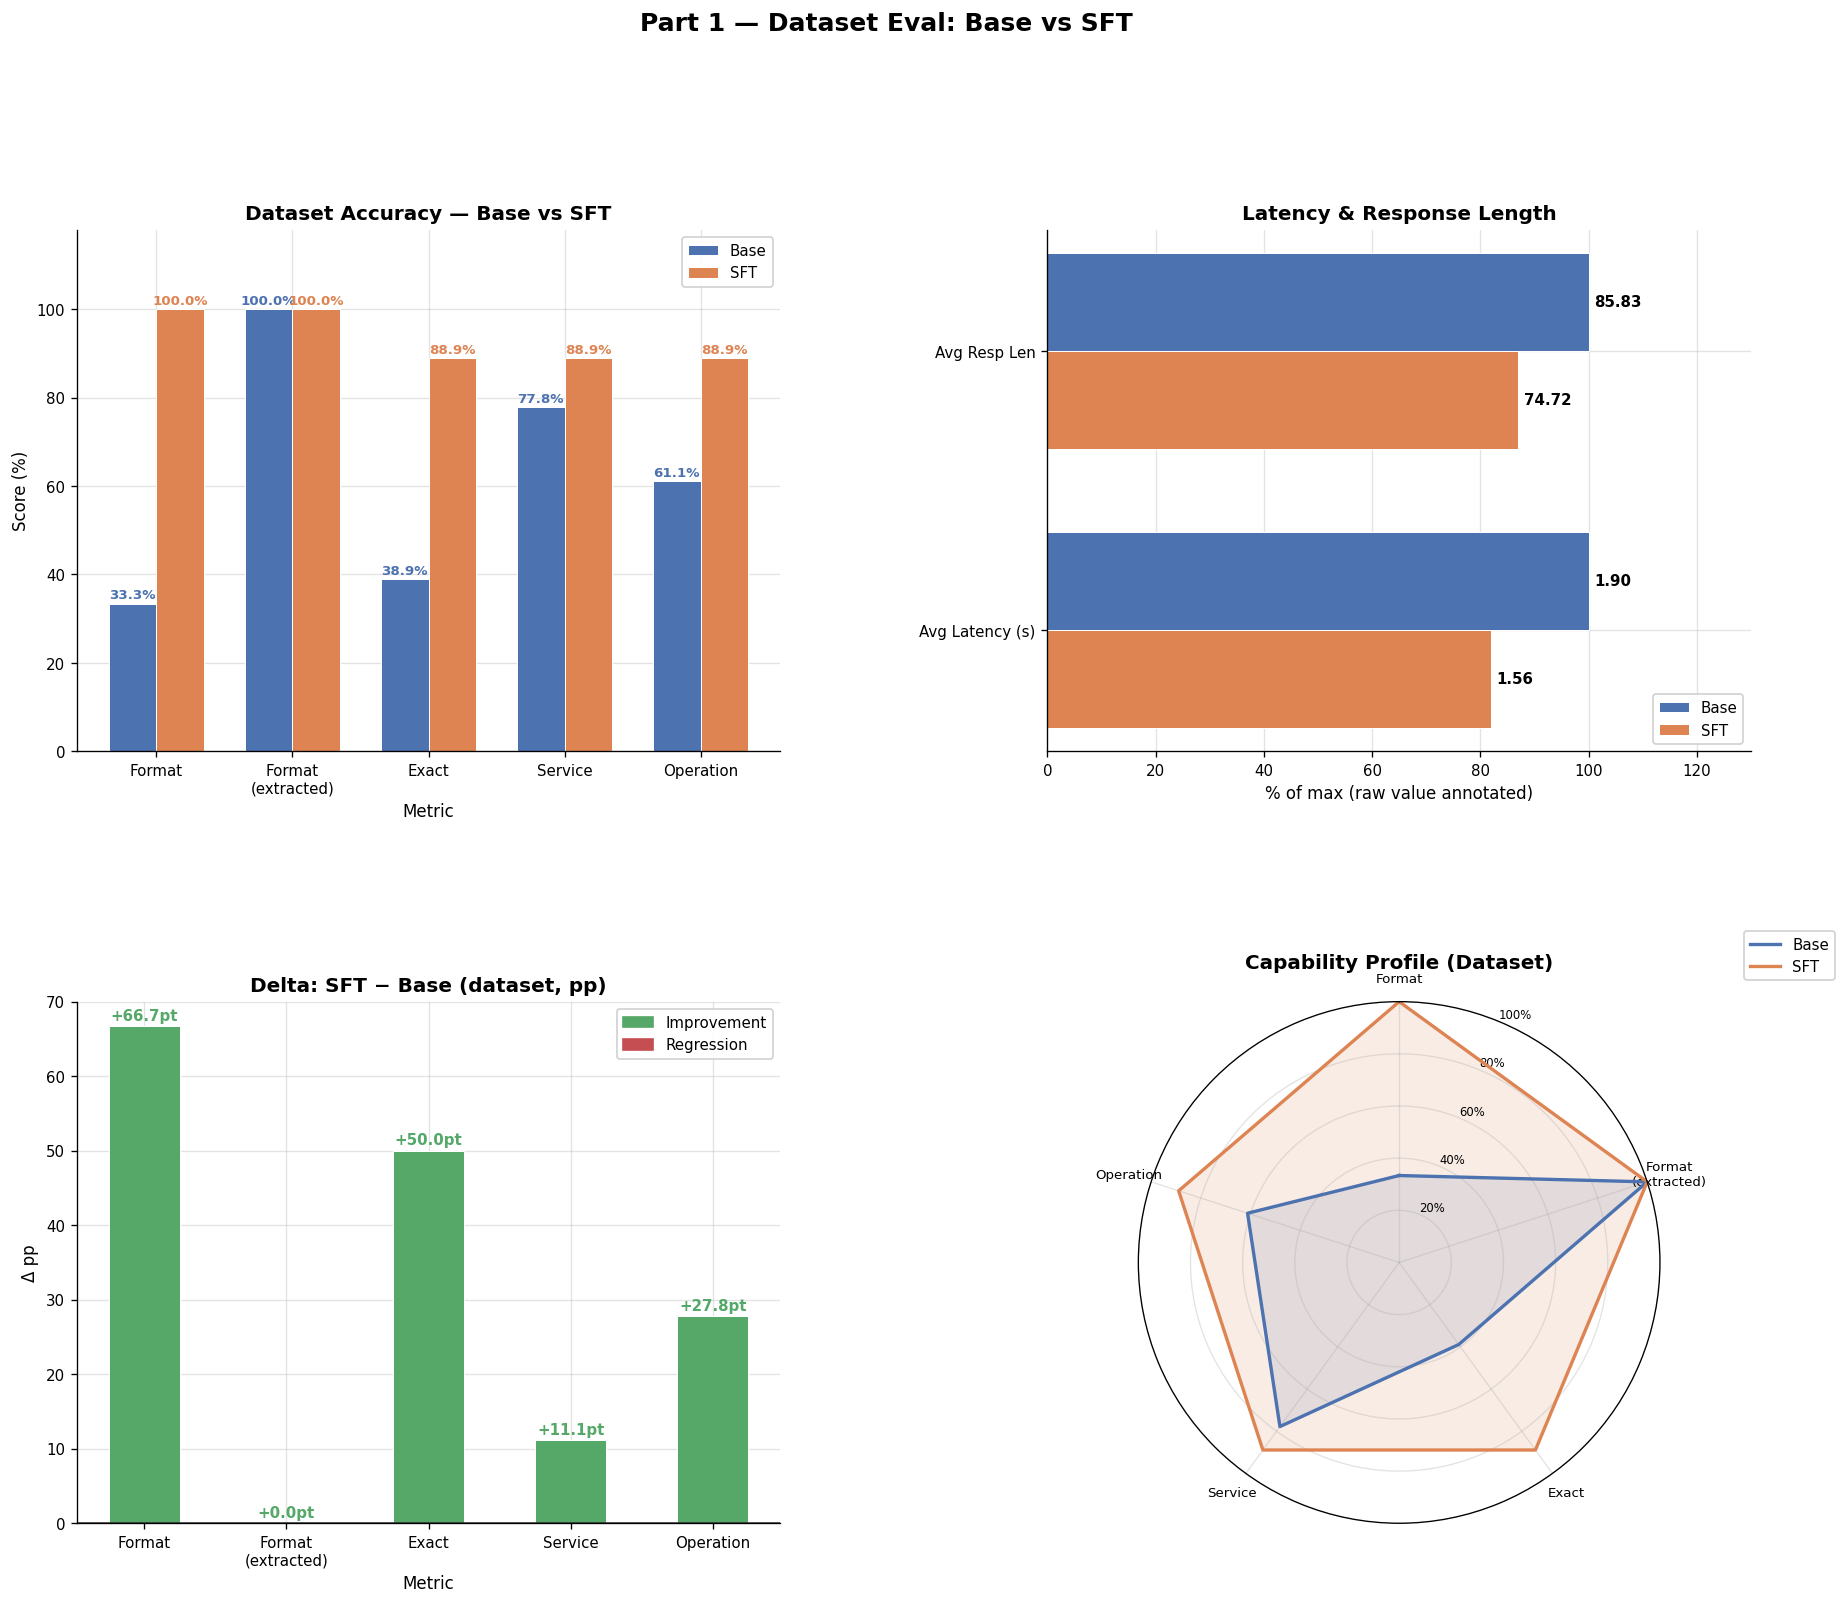

Saved → compare_dataset.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

COLOR_BASE = "#4C72B0"
COLOR_SFT  = "#DD8452"
COLOR_POS  = "#55A868"
COLOR_NEG  = "#C44E52"

plt.rcParams.update({
    "figure.dpi":        120,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "legend.framealpha": 0.9,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


# ── helper: annotate bars ───────────────────────────────────────────────────
def annotate_bars(ax, bars, fmt="{:.1f}", offset=0.5, color=None, fontsize=8):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + offset,
            fmt.format(h), ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold",
            color=color or bar.get_facecolor(),
        )


# ═══════════════════════════════════════════════════════════════════════════
# Figure 1 — Dataset eval (2x2)
# ═══════════════════════════════════════════════════════════════════════════
acc_keys   = ["format_pct", "format_after_extract_pct", "exact_pct",
              "service_pct", "operation_pct"]
acc_labels = ["Format", "Format\n(extracted)", "Exact", "Service", "Operation"]
base_acc   = [base_ds_metrics[k] * 100 for k in acc_keys]
sft_acc    = [sft_ds_metrics[k]  * 100 for k in acc_keys]
delta_acc  = [s - b for s, b in zip(sft_acc, base_acc)]

lat_labels = ["Avg Latency (s)", "Avg Resp Len"]
base_lat   = [base_ds_metrics["avg_latency"], base_ds_metrics["avg_len"]]
sft_lat    = [sft_ds_metrics["avg_latency"],  sft_ds_metrics["avg_len"]]

fig1 = plt.figure(figsize=(18, 14))
gs1  = GridSpec(2, 2, figure=fig1, hspace=0.48, wspace=0.38)
ax1, ax2 = fig1.add_subplot(gs1[0, 0]), fig1.add_subplot(gs1[0, 1])
ax3      = fig1.add_subplot(gs1[1, 0])
ax4      = fig1.add_subplot(gs1[1, 1], polar=True)

# 1a. Grouped bar — accuracy
x, w = np.arange(len(acc_labels)), 0.35
annotate_bars(ax1, ax1.bar(x - w/2, base_acc, w, color=COLOR_BASE,
              label="Base", edgecolor="white", linewidth=0.6), fmt="{:.1f}%")
annotate_bars(ax1, ax1.bar(x + w/2, sft_acc,  w, color=COLOR_SFT,
              label="SFT",  edgecolor="white", linewidth=0.6), fmt="{:.1f}%")
ax1.set(title="Dataset Accuracy — Base vs SFT", ylabel="Score (%)",
        xlabel="Metric", ylim=(0, 118))
ax1.set_xticks(x); ax1.set_xticklabels(acc_labels)
ax1.legend(); ax1.set_axisbelow(True)

# 1b. Horizontal bar — latency / length (dual x-axes not needed; normalize)
y, h = np.arange(len(lat_labels)), 0.35
# Normalize each metric independently so bars fit on one scale
max_vals = [max(base_lat[i], sft_lat[i]) for i in range(len(lat_labels))]
base_norm = [base_lat[i] / max_vals[i] * 100 for i in range(len(lat_labels))]
sft_norm  = [sft_lat[i]  / max_vals[i] * 100 for i in range(len(lat_labels))]
hb = ax2.barh(y + h/2, base_norm, h, color=COLOR_BASE, label="Base",
              edgecolor="white", linewidth=0.6)
hs = ax2.barh(y - h/2, sft_norm,  h, color=COLOR_SFT,  label="SFT",
              edgecolor="white", linewidth=0.6)
for bar, raw in zip(list(hb) + list(hs),
                    [base_lat[0], base_lat[1], sft_lat[0], sft_lat[1]]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{raw:.2f}", va="center", fontsize=9, fontweight="bold")
ax2.set(title="Latency & Response Length", xlabel="% of max (raw value annotated)")
ax2.set_yticks(y); ax2.set_yticklabels(lat_labels)
ax2.set_xlim(0, 130); ax2.legend(loc="lower right"); ax2.set_axisbelow(True)

# 1c. Delta bar
colors_d = [COLOR_POS if d >= 0 else COLOR_NEG for d in delta_acc]
bars_d   = ax3.bar(x, delta_acc, 0.5, color=colors_d, edgecolor="white", linewidth=0.6)
for bar, d in zip(bars_d, delta_acc):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.4 if d >= 0 else -1.2),
             f"{d:+.1f}pt", ha="center", va="bottom", fontsize=9, fontweight="bold",
             color=COLOR_POS if d >= 0 else COLOR_NEG)
ax3.axhline(0, color="#333", lw=0.9)
ax3.set(title="Delta: SFT − Base (dataset, pp)", ylabel="Δ pp", xlabel="Metric")
ax3.set_xticks(x); ax3.set_xticklabels(acc_labels)
ax3.legend(handles=[mpatches.Patch(color=COLOR_POS, label="Improvement"),
                    mpatches.Patch(color=COLOR_NEG, label="Regression")])
ax3.set_axisbelow(True)

# 1d. Radar
N      = len(acc_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
ax4.set_theta_offset(np.pi / 2); ax4.set_theta_direction(-1)
ax4.set_thetagrids(np.degrees(angles[:-1]), acc_labels, fontsize=8)
for vals, color, label in [(base_acc + base_acc[:1], COLOR_BASE, "Base"),
                            (sft_acc  + sft_acc[:1],  COLOR_SFT,  "SFT")]:
    ax4.plot(angles, vals, color=color, linewidth=2, label=label)
    ax4.fill(angles, vals, color=color, alpha=0.15)
ax4.set_ylim(0, 100)
ax4.set_yticks([20, 40, 60, 80, 100])
ax4.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=7)
ax4.set_title("Capability Profile (Dataset)", pad=20, fontweight="bold")
ax4.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))

fig1.suptitle("Part 1 — Dataset Eval: Base vs SFT",
              fontsize=15, fontweight="bold", y=1.01)
plt.savefig("compare_dataset.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → compare_dataset.png")

## Figure 2 — RL Env Eval (2×3)

Six panels packaged as `compare_rl_env.png`:

1. **Top-left — Avg episode reward (±std):** error bars show variance across episodes.
2. **Top-middle — Task completion rate:** percentage of episodes the model completed (`done=True`).
3. **Top-right — Steps & Reward/Step grouped:** efficiency comparison side-by-side.
4. **Bottom-left — Per-tier avg reward:** how each model scales across `warmup → expert`.
5. **Bottom-middle — Per-tier completion rate:** where each model hits a wall.
6. **Bottom-right — Reward distribution (box + jitter):** every episode's reward as an individual dot, overlaid on a box-and-whisker. The wider SFT box reflects that it tackles harder episodes (which have higher reward ceilings) — variance went up *and* the median moved up.

> **Output:** the figure is rendered inline and saved with `Saved → compare_rl_env.png`.


/tmp/ipykernel_1212/2595381142.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = rax6.boxplot(


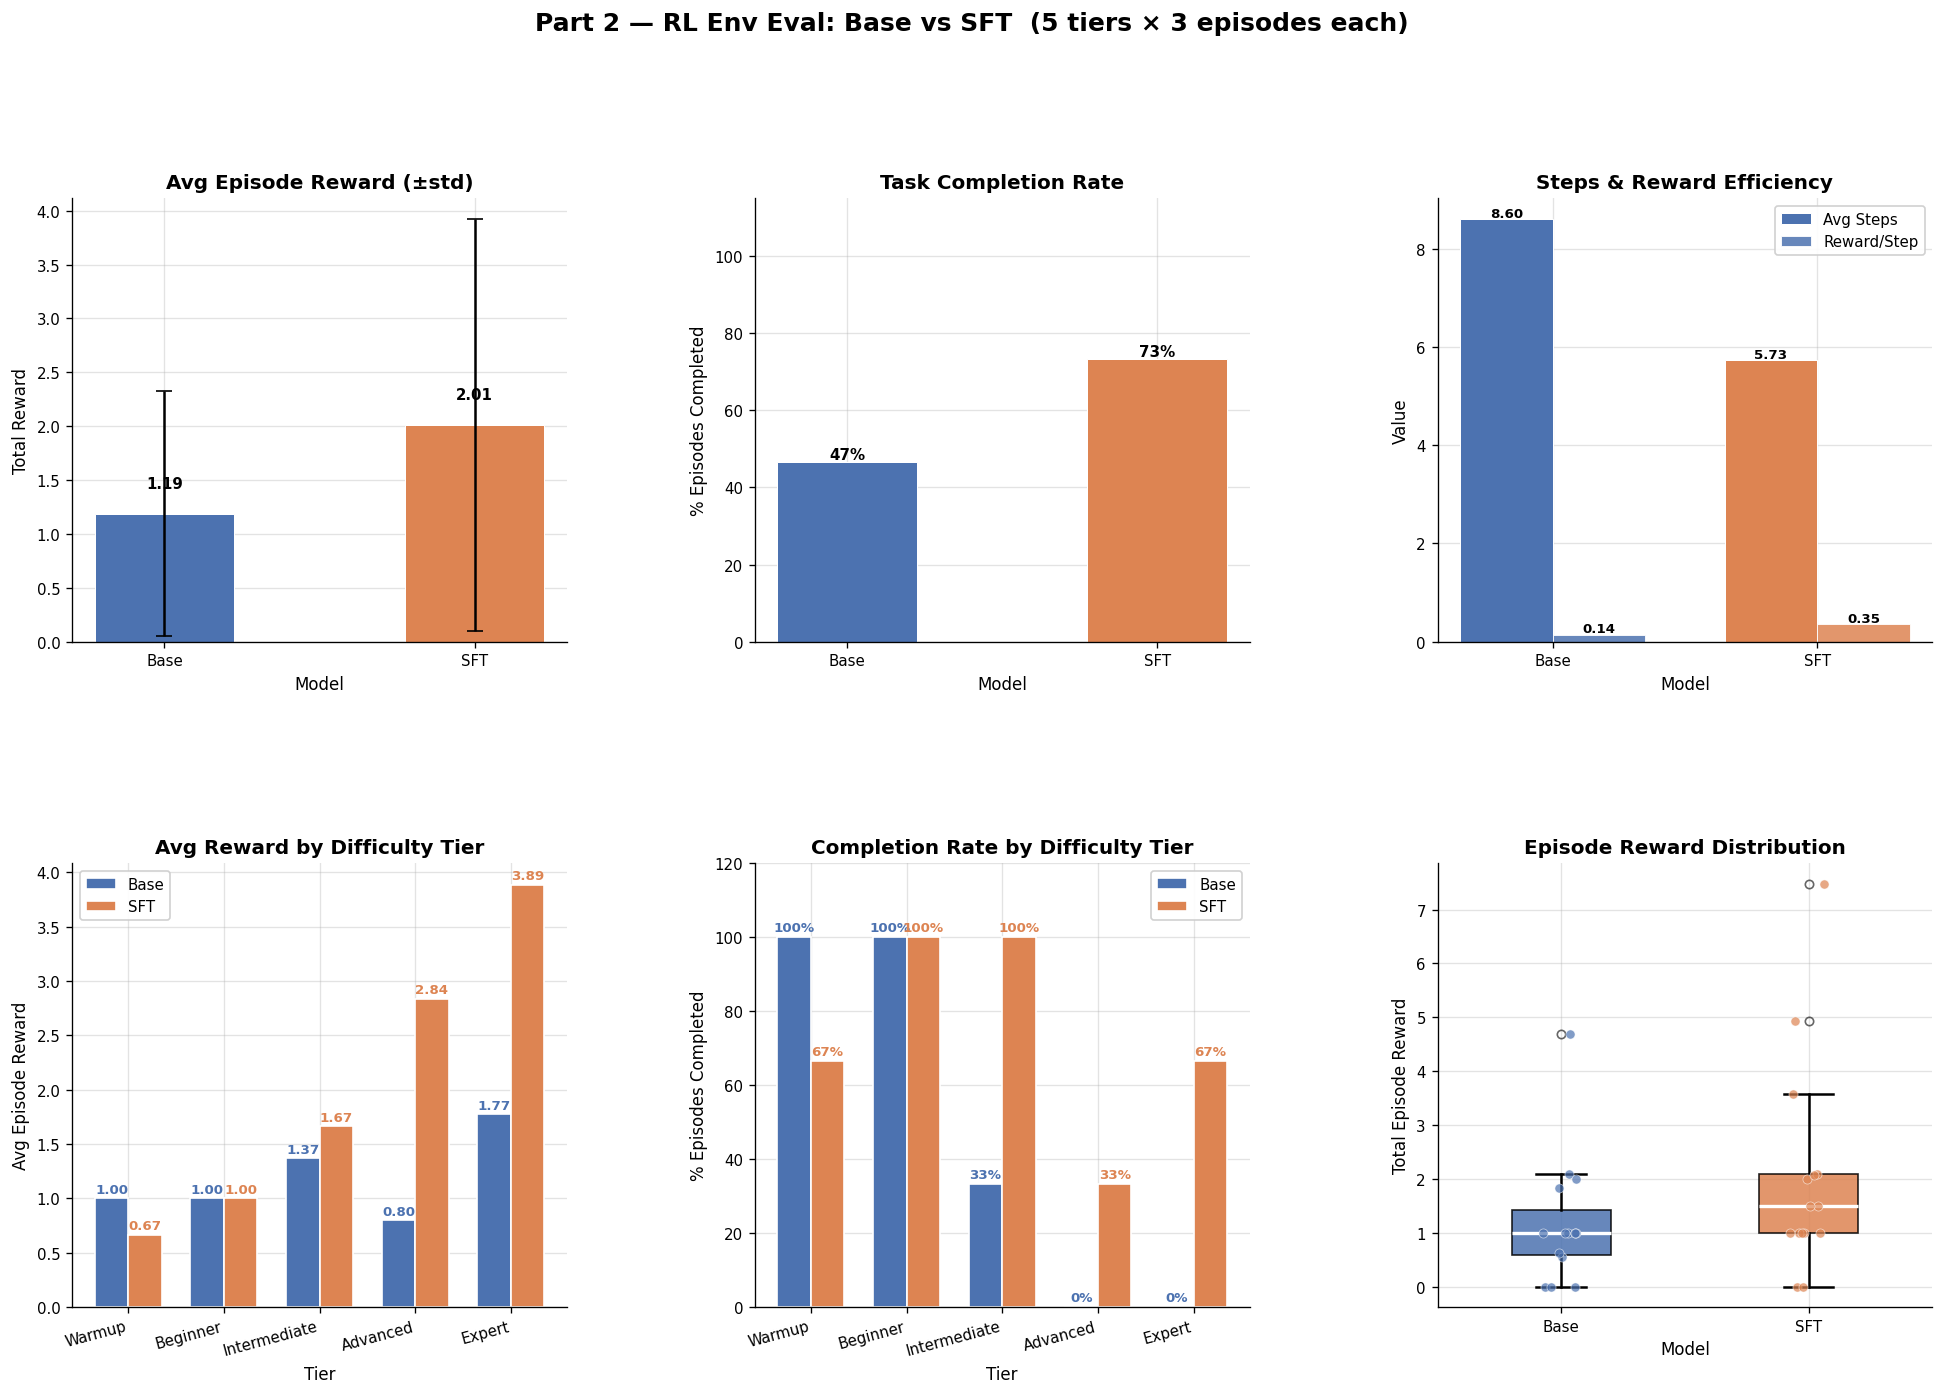

Saved → compare_rl_env.png


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# Figure 2 — RL env eval (2x3)
# ═══════════════════════════════════════════════════════════════════════════
TIER_ORDER = ["warmup", "beginner", "intermediate", "advanced", "expert"]
difficulties = [d for d in TIER_ORDER
                if d in base_rl_metrics["_per_diff"] and d in sft_rl_metrics["_per_diff"]]

fig2 = plt.figure(figsize=(20, 12))
gs2  = GridSpec(2, 3, figure=fig2, hspace=0.5, wspace=0.38)
rax1 = fig2.add_subplot(gs2[0, 0])   # avg episode reward
rax2 = fig2.add_subplot(gs2[0, 1])   # completion rate
rax3 = fig2.add_subplot(gs2[0, 2])   # avg steps & reward/step
rax4 = fig2.add_subplot(gs2[1, 0])   # per-difficulty reward
rax5 = fig2.add_subplot(gs2[1, 1])   # per-difficulty completion
rax6 = fig2.add_subplot(gs2[1, 2])   # reward distribution (box)

models     = ["Base", "SFT"]
x2         = np.arange(len(models))
bar_colors = [COLOR_BASE, COLOR_SFT]

# 2a. Avg episode reward ± std
avg_rewards = [base_rl_metrics["avg_episode_reward"], sft_rl_metrics["avg_episode_reward"]]
reward_stds = [base_rl_metrics["reward_std"],         sft_rl_metrics["reward_std"]]
bars_r = rax1.bar(x2, avg_rewards, 0.45, color=bar_colors,
                  edgecolor="white", linewidth=0.6,
                  yerr=reward_stds, capsize=5, error_kw={"elinewidth": 1.5})
for bar, v in zip(bars_r, avg_rewards):
    rax1.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + max(reward_stds) * 0.1 + 0.05,
              f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
rax1.set(title="Avg Episode Reward (±std)", ylabel="Total Reward", xlabel="Model")
rax1.set_xticks(x2); rax1.set_xticklabels(models); rax1.set_axisbelow(True)

# 2b. Task completion rate
comp_rates = [base_rl_metrics["completion_rate"] * 100,
              sft_rl_metrics["completion_rate"]  * 100]
bars_c = rax2.bar(x2, comp_rates, 0.45, color=bar_colors, edgecolor="white", linewidth=0.6)
for bar, v in zip(bars_c, comp_rates):
    rax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
              f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
rax2.set(title="Task Completion Rate", ylabel="% Episodes Completed",
         xlabel="Model", ylim=(0, 115))
rax2.set_xticks(x2); rax2.set_xticklabels(models); rax2.set_axisbelow(True)

# 2c. Avg steps + reward/step (grouped)
step_vals = [base_rl_metrics["avg_steps"],           sft_rl_metrics["avg_steps"]]
rps_vals  = [base_rl_metrics["avg_reward_per_step"], sft_rl_metrics["avg_reward_per_step"]]
w3 = 0.35
for i, (vals, label) in enumerate([(step_vals, "Avg Steps"), (rps_vals, "Reward/Step")]):
    bars_ = rax3.bar(x2 + (i - 0.5) * w3, vals, w3,
                     color=bar_colors, edgecolor="white",
                     linewidth=0.6, label=label, alpha=0.85 if i else 1.0)
    for bar, v in zip(bars_, vals):
        rax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                  f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")
rax3.set(title="Steps & Reward Efficiency", ylabel="Value", xlabel="Model")
rax3.set_xticks(x2); rax3.set_xticklabels(models)
rax3.legend(loc="upper right"); rax3.set_axisbelow(True)

# 2d. Per-difficulty avg reward (all 5 tiers)
xd, wd   = np.arange(len(difficulties)), 0.35
base_dr  = [base_rl_metrics["_per_diff"][d]["avg_reward"] for d in difficulties]
sft_dr   = [sft_rl_metrics["_per_diff"][d]["avg_reward"]  for d in difficulties]
annotate_bars(rax4, rax4.bar(xd - wd/2, base_dr, wd, color=COLOR_BASE,
              label="Base", edgecolor="white"), fmt="{:.2f}", offset=0.02)
annotate_bars(rax4, rax4.bar(xd + wd/2, sft_dr,  wd, color=COLOR_SFT,
              label="SFT",  edgecolor="white"), fmt="{:.2f}", offset=0.02)
rax4.set(title="Avg Reward by Difficulty Tier", ylabel="Avg Episode Reward", xlabel="Tier")
rax4.set_xticks(xd)
rax4.set_xticklabels([d.capitalize() for d in difficulties], rotation=15, ha="right")
rax4.legend(); rax4.set_axisbelow(True)

# 2e. Per-difficulty completion rate (all 5 tiers)
base_dc = [base_rl_metrics["_per_diff"][d]["completion_rate"] * 100 for d in difficulties]
sft_dc  = [sft_rl_metrics["_per_diff"][d]["completion_rate"]  * 100 for d in difficulties]
annotate_bars(rax5, rax5.bar(xd - wd/2, base_dc, wd, color=COLOR_BASE,
              label="Base", edgecolor="white"), fmt="{:.0f}%", offset=0.8)
annotate_bars(rax5, rax5.bar(xd + wd/2, sft_dc,  wd, color=COLOR_SFT,
              label="SFT",  edgecolor="white"), fmt="{:.0f}%", offset=0.8)
rax5.set(title="Completion Rate by Difficulty Tier",
         ylabel="% Episodes Completed", xlabel="Tier", ylim=(0, 120))
rax5.set_xticks(xd)
rax5.set_xticklabels([d.capitalize() for d in difficulties], rotation=15, ha="right")
rax5.legend(); rax5.set_axisbelow(True)

# 2f. Reward distribution — box + jitter
bp = rax6.boxplot(
    [base_rl_metrics["_rewards"], sft_rl_metrics["_rewards"]],
    labels=["Base", "SFT"],
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.6},
    widths=0.4,
)
for patch, color in zip(bp["boxes"], [COLOR_BASE, COLOR_SFT]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
for i, (rewards, color) in enumerate(
    [(base_rl_metrics["_rewards"], COLOR_BASE),
     (sft_rl_metrics["_rewards"],  COLOR_SFT)], start=1
):
    jitter = np.random.uniform(-0.08, 0.08, len(rewards))
    rax6.scatter(np.full(len(rewards), i) + jitter, rewards,
                 color=color, alpha=0.7, zorder=3, s=30,
                 edgecolors="white", linewidths=0.4)
rax6.set(title="Episode Reward Distribution",
         ylabel="Total Episode Reward", xlabel="Model")
rax6.set_axisbelow(True)

fig2.suptitle(
    f"Part 2 — RL Env Eval: Base vs SFT  "
    f"({len(difficulties)} tiers × {RL_EPISODES_PER_DIFF} episodes each)",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.savefig("compare_rl_env.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → compare_rl_env.png")

## 📋 Numerical Summary

Side-by-side table of every metric in both eval modes, plus a delta column. This is the print-friendly version of what the plots show.

> **Output highlights:**
>
> - Dataset format compliance: **33.3% → 100% (+66.7 pp)**
> - Dataset exact match: **38.9% → 88.9% (+50.0 pp)**
> - RL env completion rate: **46.7% → 73.3% (+26.7 pp)**
> - RL env reward per step: **0.138 → 0.351 (+154%)**
> - Latency went **down** in both modes — SFT generates fewer tokens because it stopped padding output with prose.
>
> The reward standard deviation rose (`+0.77`); that's expected — the SFT model attempts the harder tiers, so per-episode reward swings between low (timeout) and high (jackpot) instead of clustering near the easy-task ceiling. **More variance is a feature here, not a bug** — it means the model is engaging with episodes the base couldn't even start.


In [29]:
print("=" * 72)
print("DATASET EVAL SUMMARY")
print("=" * 72)
ds_keys = ["format_pct", "format_after_extract_pct", "exact_pct",
           "service_pct", "operation_pct", "avg_latency", "avg_len"]
print(f"{'Metric':<30} {'Base':>10} {'SFT':>10} {'Delta':>12}")
print("-" * 64)
for k in ds_keys:
    b, s = base_ds_metrics[k], sft_ds_metrics[k]
    if "pct" in k:
        print(f"{k:<30} {100*b:9.1f}% {100*s:9.1f}% {100*(s-b):+11.1f}pt")
    else:
        print(f"{k:<30} {b:10.3f} {s:10.3f} {s-b:+12.3f}")

print()
print("=" * 72)
print("RL ENV EVAL SUMMARY")
print("=" * 72)
rl_keys = ["avg_episode_reward", "reward_std", "completion_rate",
           "avg_steps", "avg_reward_per_step"]
print(f"{'Metric':<25} {'Base':>10} {'SFT':>10} {'Delta':>12}")
print("-" * 60)
for k in rl_keys:
    b, s = base_rl_metrics[k], sft_rl_metrics[k]
    if k == "completion_rate":
        print(f"{k:<25} {100*b:9.1f}% {100*s:9.1f}% {100*(s-b):+11.1f}pt")
    else:
        print(f"{k:<25} {b:10.3f} {s:10.3f} {s-b:+12.3f}")

DATASET EVAL SUMMARY
Metric                               Base        SFT        Delta
----------------------------------------------------------------
format_pct                          33.3%     100.0%       +66.7pt
format_after_extract_pct           100.0%     100.0%        +0.0pt
exact_pct                           38.9%      88.9%       +50.0pt
service_pct                         77.8%      88.9%       +11.1pt
operation_pct                       61.1%      88.9%       +27.8pt
avg_latency                         1.901      1.559       -0.342
avg_len                            85.833     74.722      -11.111

RL ENV EVAL SUMMARY
Metric                          Base        SFT        Delta
------------------------------------------------------------
avg_episode_reward             1.187      2.011       +0.824
reward_std                     1.137      1.908       +0.771
completion_rate                46.7%      73.3%       +26.7pt
avg_steps                      8.600      5.733       